<a href="https://colab.research.google.com/github/Kashyyaap/AI-ML_Internship/blob/main/Day_3(part_c).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("wine_quality_merged.csv")

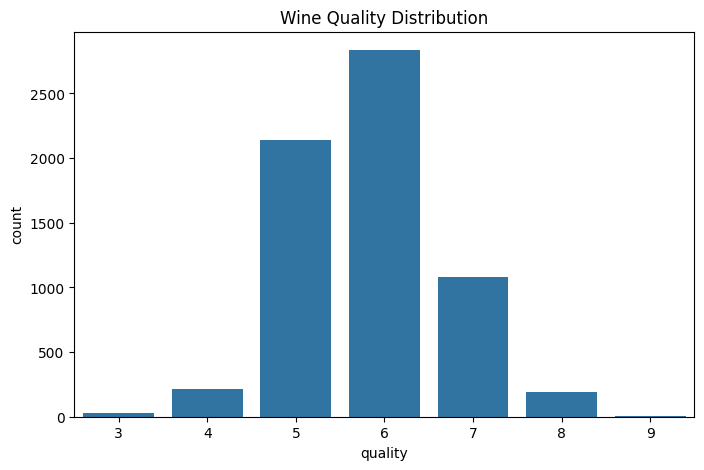

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='quality', data=df)
plt.title('Wine Quality Distribution')
plt.show()

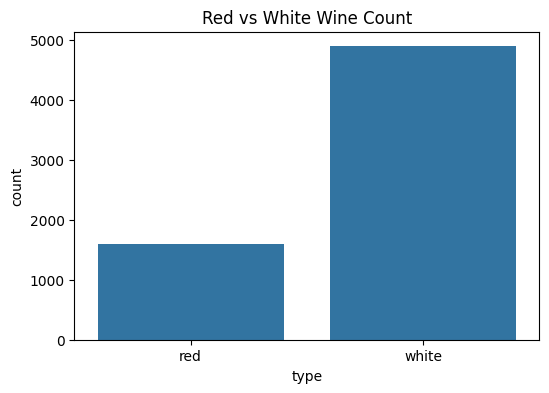

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='type', data=df)
plt.title('Red vs White Wine Count')
plt.show()

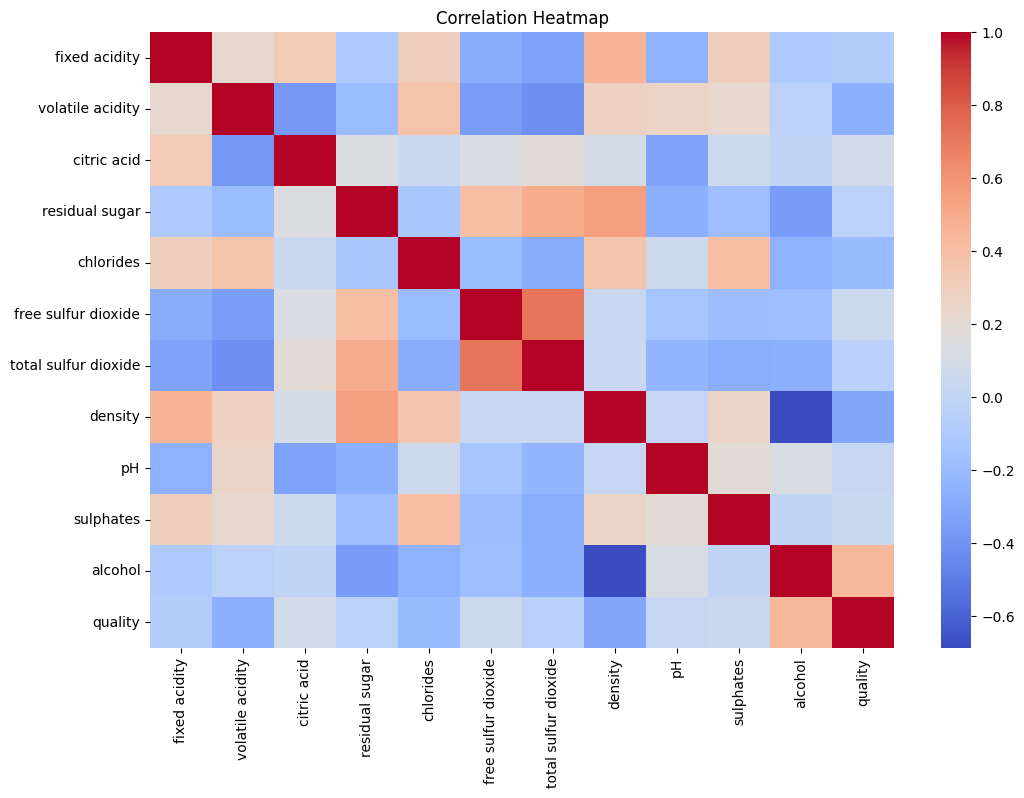

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include='number').corr(),
            cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

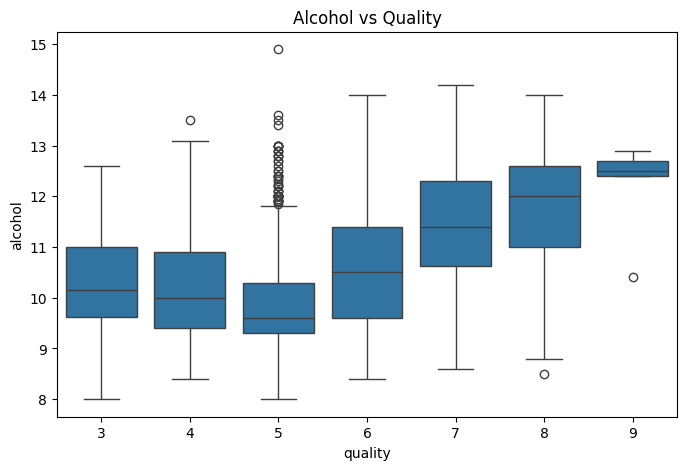

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='quality', y='alcohol', data=df)
plt.title('Alcohol vs Quality')
plt.show()

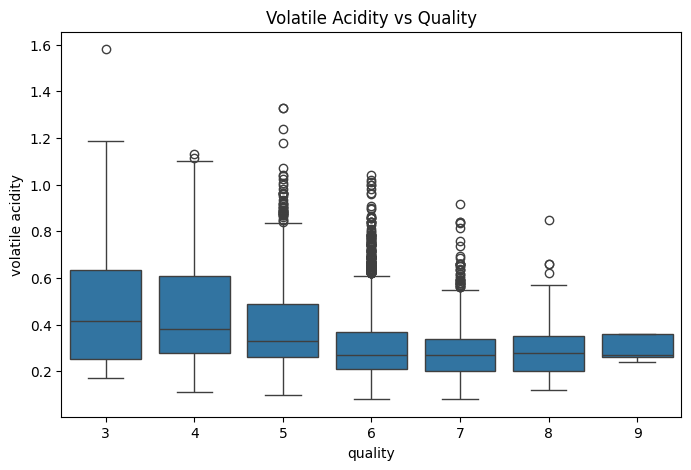

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='quality', y='volatile acidity', data=df)
plt.title('Volatile Acidity vs Quality')
plt.show()

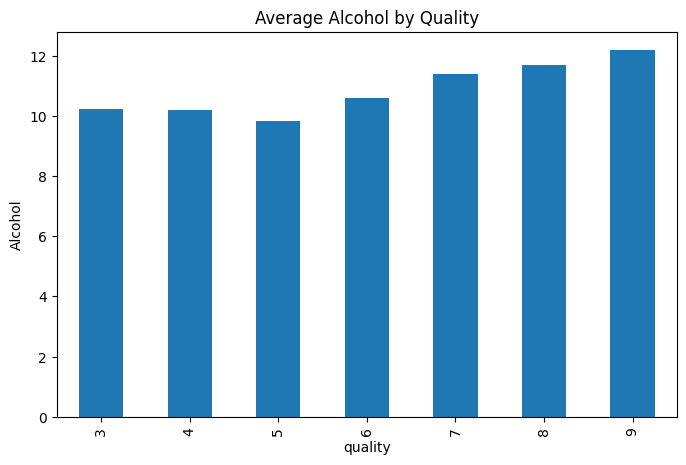

In [ ]:
avg_alcohol = df.groupby('quality')['alcohol'].mean()

plt.figure(figsize=(8,5))
avg_alcohol.plot(kind='bar')
plt.title('Average Alcohol by Quality')
plt.ylabel('Alcohol')
plt.show()

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("wine_quality_merged.csv")

# Encode target
df['type'] = df['type'].map({'red':0, 'white':1})

# Features and target
X = df.drop('type', axis=1)
y = df['type']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9961538461538462

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       320
           1       1.00      1.00      1.00       980

    accuracy                           1.00      1300
   macro avg       0.99      1.00      0.99      1300
weighted avg       1.00      1.00      1.00      1300

